# 올리브영 랭킹 알고리즘 추정 — 스킨케어 > 에센스/세럼/앰플

**1주제**: 포털의 랭킹 알고리즘 추정

**분석 질문**: 검색 결과 상위 노출("인기순")은 리뷰수·평점·가격 중 무엇과 관련 있는가?

**대상 페이지**: 올리브영 스킨케어 > 에센스/세럼/앰플 카테고리, 인기순 정렬(다른 정렬은 판매량·최신성 등 단일 지표가 순위를 결정하므로, 질문에 대한 답이 이미 정해져 있어 분석 대상에서 제외), 상위 50개
`https://www.oliveyoung.co.kr/store/display/getMCategoryList.do?dispCatNo=1000001000100140001&prdSort=01`

**수집 시점**: 2026-07-23

**수집 컬럼**: 순위(노출 순서), 상품명, 가격, 리뷰수(또는 후기수), 평점

**절차**
1. 카테고리 목록 페이지에서 순위·브랜드·상품명·가격·평점(추정)·goodsNo를 수집한다.
2. 목록 페이지는 리뷰수를 `999+`로 뭉개서 보여주므로, 각 상품 상세페이지를 헤드리스 브라우저로 직접 렌더링해 **정확한 리뷰수**를 다시 수집한다.
3. 순위와 각 지표(리뷰수/평점/가격/할인율) 사이의 스피어만·상관계수를 계산한다.
4. 산점도로 시각화하고 결론을 정리한다.

**예상 결과와 한계**
- 예상: 리뷰수·평점이 높을수록 상위 노출될 가능성이 있으나, 가격은 뷰티 카테고리 특성상(고가 프리미엄 vs 저가 인기템 혼재) 뚜렷한 방향성이 없을 것으로 예상
- 한계: 이 방법으로는 "관련이 있어 보이는지"까지만 확인 가능하며, 인기순 알고리즘의 정확한 가중치나 인과관계까지는 알 수 없음

## 0. 환경 준비

In [ ]:
!pip uninstall -y lxml
!pip install --force-reinstall --no-cache-dir lxml

In [ ]:
# 최초 1회만 실행
!pip install curl_cffi beautifulsoup4 lxml playwright pandas scipy matplotlib
!playwright install chromium


In [6]:
import re
import time
import json
import pandas as pd
import numpy as np
from scipy import stats
from bs4 import BeautifulSoup
from curl_cffi import requests as cf_requests


## 1. 카테고리 목록 페이지 수집

`www.oliveyoung.co.kr`은 일반 `requests`로는 403이 뜨는 경우가 있어, TLS 지문을 흉내내는
`curl_cffi`(`impersonate="safari"`)를 사용한다. `rowsPerPage=50`으로 요청하면 인기순 상위 50개를
한 페이지에서 받아올 수 있다.

In [7]:
LIST_URL = (
    "https://www.oliveyoung.co.kr/store/display/getMCategoryList.do"
    "?dispCatNo=1000001000100140001&fltDispCatNo=&prdSort=01"
    "&pageIdx=1&rowsPerPage=50&searchTypeSort=btn_thumb"
    "&plusButtonFlag=N&isLoginCnt=&trackingCd=Cat1000001000100140001_Small"
)

resp = cf_requests.get(
    LIST_URL,
    impersonate="safari",
    headers={"Referer": "https://www.oliveyoung.co.kr/"},
    timeout=25,
)
print(resp.status_code, len(resp.text))
list_html = resp.text


200 346070


## 2. 목록 페이지 파싱

상품 리스트는 `<li data-number="N">` 블록 단위로 반복된다. `lxml` 파서에 전체 HTML을 통째로
넣으면 5번째 상품(베스트 리본이 있는 항목)부터 트리가 깨지는 문제가 있어, 정규식으로 각 `<li>`
블록을 먼저 잘라낸 뒤 블록별로 개별 파싱한다.

평점은 화면에 보이는 "10점만점에 5.5점(999+)" 텍스트가 실제 값이 아니라 자바스크립트가 채우기
전의 스크린리더용 placeholder다. 실제 평점은 별점 바의 `style="width:96.0%"` 값이며,
`퍼센트 ÷ 20 = 5점 만점 평점`이다 (96% → 4.8점).

In [8]:
def parse_list_page(html, max_rank=50):
    starts = [m.start() for m in re.finditer(r'<li criteo-goods="[^"]*"[^>]*data-number="\d+">', html)]
    starts.append(len(html))

    rows = []
    for i in range(len(starts) - 1):
        frag = html[starts[i]:starts[i + 1]]
        m = re.search(r'data-number="(\d+)"', frag)
        rank = int(m.group(1))
        if rank > max_rank:
            continue

        goods_m = re.search(r'data-ref-goodsNo="([^"]+)"', frag)
        goods_no = goods_m.group(1) if goods_m else None

        soup = BeautifulSoup(frag, "lxml")
        brand = (soup.select_one(".tx_brand") or {}).get_text(strip=True) if soup.select_one(".tx_brand") else ""
        name = soup.select_one(".tx_name").get_text(strip=True) if soup.select_one(".tx_name") else ""

        cur_tag = soup.select_one(".prd_price .tx_cur .tx_num")
        org_tag = soup.select_one(".prd_price .tx_org .tx_num")
        price = cur_tag.get_text(strip=True) if cur_tag else (soup.select_one(".prd_price .tx_num") or {}).get_text(strip=True)
        org_price = org_tag.get_text(strip=True) if org_tag else None

        point_tag = soup.select_one(".review_point .point")
        rating = None
        if point_tag and point_tag.get("style"):
            wm = re.search(r"width\s*:\s*([\d.]+)%", point_tag["style"])
            if wm:
                rating = round(float(wm.group(1)) / 20, 1)

        point_area = soup.select_one(".prd_point_area")
        review_capped = None
        if point_area:
            cm = re.search(r"\(([^)]+)\)", point_area.get_text(" ", strip=True))
            if cm:
                review_capped = cm.group(1)

        rows.append({
            "rank": rank, "goods_no": goods_no, "brand": brand, "name": name,
            "price": price, "org_price": org_price, "rating": rating,
            "review_count_capped": review_capped,
        })

    rows.sort(key=lambda r: r["rank"])
    return rows


listing = parse_list_page(list_html, max_rank=50)
print(len(listing), "products parsed")
listing[0]


50 products parsed


{'rank': 1,
 'goods_no': 'A000000258445',
 'brand': '퍼셀',
 'name': '[7/23하루특가/대용량] 퍼셀 20억/mL 픽셀바이옴 원액 55ml',
 'price': '35,900',
 'org_price': '59,000',
 'rating': 4.8,
 'review_count_capped': '999+'}

## 3. 상세페이지에서 정확한 리뷰수 수집

상품 상세페이지(`getGoodsDetail.do`)는 Next.js로 렌더링되며, 리뷰수는 서버 HTML에 없고
클라이언트에서 API를 호출한 뒤 하이드레이션되며 채워진다. 정적 HTML 파싱으로는 얻을 수 없어
Playwright로 실제 페이지를 렌더링해 텍스트에서 "평점 / 리뷰 N건" 패턴을 읽는다.

**수정 사항** : "Jupyter의 비동기 루프와 Playwright의 동기 API가 충돌해서, 크롤링 코드를 함수로 묶어 별도 스레드에서 돌렸고, Windows에서 그 스레드가 브라우저 서브프로세스를 띄울 수 있도록 이벤트 루프 정책을 추가했다."

In [9]:
from playwright.sync_api import sync_playwright
import threading
import asyncio
import sys

UA = ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 "
      "(KHTML, like Gecko) Version/17.4 Safari/605.1.15")

rating_re = re.compile(r"평점\s*\n?\s*([\d.]+)\s*\n\s*리뷰\s*([\d,]+)\s*건")
review_only_re = re.compile(r"리뷰\s*([\d,]+)\s*건")


def fetch_exact_review(page, goods_no, retries=2):
    url = f"https://www.oliveyoung.co.kr/store/goods/getGoodsDetail.do?goodsNo={goods_no}"
    for attempt in range(retries + 1):
        page.goto(url, wait_until="domcontentloaded", timeout=30000)
        page.wait_for_timeout(2500 if attempt == 0 else 4000)
        text = page.inner_text("body")
        m = rating_re.search(text)
        if m:
            return float(m.group(1)), int(m.group(2).replace(",", ""))
        m2 = review_only_re.search(text)
        if m2:
            return None, int(m2.group(1).replace(",", ""))
    return None, None


def run_scraper():
    # Windows에서 스레드 내 subprocess 지원을 위해 이벤트 루프 정책을 명시적으로 설정
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

    results = []
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        context = browser.new_context(user_agent=UA, viewport={"width": 1280, "height": 2000}, locale="ko-KR")
        page = context.new_page()

        for row in listing:
            exact_rating, exact_review = fetch_exact_review(page, row["goods_no"])
            row["exact_rating"] = exact_rating if exact_rating is not None else row["rating"]
            row["exact_review_count"] = exact_review
            results.append(row)
            print(row["rank"], row["goods_no"], row["exact_rating"], row["exact_review_count"])
            time.sleep(0.6)

        browser.close()
    return results


result_holder = {}
def _wrapper():
    try:
        result_holder["results"] = run_scraper()
    except Exception as e:
        result_holder["error"] = e

t = threading.Thread(target=_wrapper)
t.start()
t.join()

if "error" in result_holder:
    raise result_holder["error"]

results = result_holder["results"]

1 A000000258445 4.8 2251
2 A000000222698 4.8 12767
3 A000000259488 4.8 14855
4 A000000231885 4.8 9723
5 A000000255620 4.7 25246
6 A000000158615 4.7 12249
7 A000000200646 4.7 21879
8 A000000226201 4.8 5178
9 A000000224494 4.7 5094
10 A000000211119 4.7 42766
11 A000000219609 4.9 75150
12 A000000231822 4.8 13497
13 A000000258877 5.0 2739
14 A000000255227 4.8 9524
15 A000000250199 4.8 2154
16 A000000260346 5.0 106
17 A000000254661 4.9 691
18 A000000258291 4.9 3832
19 A000000188065 4.7 26739
20 A000000250531 5.0 238
21 A000000183707 4.8 3415
22 A000000207225 4.7 15183
23 A000000225217 4.8 12139
24 A000000188004 4.8 13229
25 A000000184060 4.9 15201
26 A000000232436 4.7 13949
27 A000000259221 4.8 2260
28 A000000255701 4.8 3193
29 A000000243677 4.8 9483
30 A000000258676 4.8 3103
31 A000000255719 4.8 1681
32 A000000232212 4.8 50389
33 A000000230206 4.8 16252
34 A000000250773 4.8 6061
35 A000000189837 4.7 19688
36 A000000258649 4.8 3334
37 A000000229790 4.8 5979
38 A000000250225 4.9 2671
39 A000

## 4. 데이터프레임 정리 및 파생 변수 계산

In [ ]:
df = pd.DataFrame(results)
df["price_num"] = df["price"].str.replace(",", "").astype(int)
df["org_price_num"] = df["org_price"].apply(
    lambda x: int(str(x).replace(",", "")) if pd.notna(x) else None
)
df["discount_pct"] = (1 - df["price_num"] / df["org_price_num"]) * 100

df.to_csv("oliveyoung_top50_essence_serum.csv", index=False, encoding="utf-8-sig")
df.head(10)

,rank,goods_no,brand,name,price,org_price,rating,review_count_capped,exact_rating,exact_review_count,price_num,org_price_num,discount_pct
0,1,A000000258445,퍼셀,[7/23하루특가/대용량] 퍼셀 20억/mL 픽셀바이옴 원액 55ml,"35,900","59,000",4.8,999+,4.8,2251,35900,59000.0,39.152542
1,2,A000000222698,아누아,[수지세럼] 아누아 피디알엔 히알루론산 캡슐 100 세럼 30mL 기획 (+30mL...,"27,500","58,500",4.8,999+,4.8,12767,27500,58500.0,52.991453
2,3,A000000259488,파넬,[7월올영픽/최초대용량] 파넬 시카마누 92세럼 50ml 더블기획 (총 100ml),"29,900","52,000",4.8,999+,4.8,14855,29900,52000.0,42.500000
3,4,A000000231885,웰라쥬,[속건조필수템] 웰라쥬 리얼 히알루로닉 블루 100 앰플 75ml 2입 기획,"29,900","50,000",4.8,999+,4.8,9723,29900,50000.0,40.200000
4,5,A000000255620,메디큐브,[1등미백앰플]메디큐브 PDRN 핑크 펩타이드 앰플 30ml 리필기획(+리필팩50m...,"24,600","46,000",4.7,999+,4.7,25246,24600,46000.0,46.521739
5,6,A000000158615,디오디너리,[트러블모공] 디오디너리 나이아신아마이드 10% + 징크 1% 60ml,"15,700",NaN,4.7,999+,4.7,12249,15700,NaN,NaN
6,7,A000000200646,브링그린,[7월올영픽/3일진정세럼]브링그린 징크테카 트러블 세럼 대용량 기획,"28,900","56,100",4.7,999+,4.7,21879,28900,56100.0,48.484848
7,8,A000000226201,아누아,[단독기획] 아누아 TXA 나이아신 흔적 세럼 30ml 2입,"27,500","64,000",4.8,999+,4.8,5178,27500,64000.0,57.031250
8,9,A000000224494,셀라딕스,[조유리 PICK/트러블1등] 셀라딕스 트러블 세범 리밸런싱 131 앰플 30ml,"25,400","28,900",4.7,999+,4.7,5094,25400,28900.0,12.110727
9,10,A000000211119,메디힐,[장도연 PICK] 메디힐 마데카소사이드 흔적 리페어 세럼 40+40ml,"22,900","36,900",4.7,999+,4.7,42766,22900,36900.0,37.940379


In [28]:
# 컬럼 선별 
# 필수 칼럼 : rank(인기 순위), price_num(판매가), exact_rating(평점), exact_review_count(리뷰수)
# 보조 칼렁 : brand(브랜드명), name(제품명), > 식별용 / org_price_num(정가), discount_pct(할인율) > 보조변수

# 버릴 칼럼 : 
# price, org_price (문자열 버전, 숫자 버전 있으니 필요없음)
# review_count_capped (999+로 뭉개져서 못 씀)
# rating (더 정확한 exact_rating이 있으니)

cols_to_keep = [
    "rank", "brand", "name",
    "price_num", "org_price_num",
    "exact_rating", "exact_review_count",
    "discount_pct"
]

olive = df[cols_to_keep].copy()

print(olive.columns.tolist())
olive.head()

['rank', 'brand', 'name', 'price_num', 'org_price_num', 'exact_rating', 'exact_review_count', 'discount_pct']


,rank,brand,name,price_num,org_price_num,exact_rating,exact_review_count,discount_pct
0,1,퍼셀,[7/23하루특가/대용량] 퍼셀 20억/mL 픽셀바이옴 원액 55ml,35900,59000.0,4.8,2251,39.152542
1,2,아누아,[수지세럼] 아누아 피디알엔 히알루론산 캡슐 100 세럼 30mL 기획 (+30mL...,27500,58500.0,4.8,12767,52.991453
2,3,파넬,[7월올영픽/최초대용량] 파넬 시카마누 92세럼 50ml 더블기획 (총 100ml),29900,52000.0,4.8,14855,42.500000
3,4,웰라쥬,[속건조필수템] 웰라쥬 리얼 히알루로닉 블루 100 앰플 75ml 2입 기획,29900,50000.0,4.8,9723,40.200000
4,5,메디큐브,[1등미백앰플]메디큐브 PDRN 핑크 펩타이드 앰플 30ml 리필기획(+리필팩50m...,24600,46000.0,4.7,25246,46.521739


## 5. 데이터 품질 확인

### 구조, 결측, 중복, 타입

In [29]:
print("[구조]", olive.shape, f"{olive.memory_usage(deep=True).sum()/1024:.1f}KB")

print("\n[결측치]")
print(olive.isna().sum()[olive.isna().sum() > 0]) 

print("\n[중복] 전체:", olive.duplicated().sum(), "| name 기준:", olive.duplicated(subset=['name']).sum())

# 의심 컬럼 탐지: 숫자여야 할 것 같은데 object/str로 잡힌 컬럼
suspect = [c for c in olive.columns if olive[c].dtype == object or str(olive[c].dtype) == 'str']
suspect = [c for c in suspect if c not in ['brand', 'name']]  # 원래 텍스트인 컬럼은 제외
print()
if suspect:
    print(f"⚠️ 의심 컬럼(숫자 예상되나 텍스트형): {suspect}")
else:
    print("의심 컬럼 없음 — 모든 숫자 컬럼이 숫자형으로 잘 들어옴")

[구조] (50, 8) 8.6KB

[결측치]
org_price_num    3
discount_pct     3
dtype: int64

[중복] 전체: 0 | name 기준: 0

의심 컬럼 없음 — 모든 숫자 컬럼이 숫자형으로 잘 들어옴


## 6. 데이터 정제

- 품질 확인에서 발견된 결측치는 할인 없이 정가 = 판매가로 팔린 상품 `discount_pct`는 0 으로, `org_price_num`은 `price_num`과 같은 값으로 채움
- 이외에 정제 사항 (날짜 파싱, 문자열 정제, 이상치 처리 등) 없음

In [25]:
olive["org_price_num"] = olive["org_price_num"].fillna(olive["price_num"])
olive["discount_pct"] = olive["discount_pct"].fillna(0)

print(olive.isna().sum().sum(), "개 남음")
olive[olive["discount_pct"] == 0]

0 개 남음


,rank,brand,name,price_num,org_price_num,exact_rating,exact_review_count,discount_pct
5,6,디오디너리,[트러블모공] 디오디너리 나이아신아마이드 10% + 징크 1% 60ml,15700,15700.0,4.7,12249,0.0
17,18,토리든,[NEW/1등수분세럼] 토리든 다이브인 저분자 히알루론산 세럼 50ml 리필 기획(...,36000,36000.0,4.9,3832,0.0
18,19,디오디너리,[단독/대용량] 디오디너리 나이아신아마이드 10% + 징크 1% 120ml,28900,28900.0,4.7,26739,0.0


## 7. 상관분석 진행

인기순위와 각각의 지표별 상관분석 진행 `rank`변수가 서열형이기 때문에 스피어만 상관계수(ρ) 사용

In [34]:
from scipy import stats

vars_to_test = ['exact_review_count', 'exact_rating', 'price_num']

for v in vars_to_test:
    rho, p = stats.spearmanr(olive['rank'], olive[v])
    sig = "유의함(p<0.05)" if p < 0.05 else "유의하지 않음"
    print(f"{v:22s} rho={rho:+.3f}  p={p:.3f}  -> {sig}")

exact_review_count     rho=-0.107  p=0.460  -> 유의하지 않음
exact_rating           rho=+0.213  p=0.138  -> 유의하지 않음
price_num              rho=-0.089  p=0.537  -> 유의하지 않음


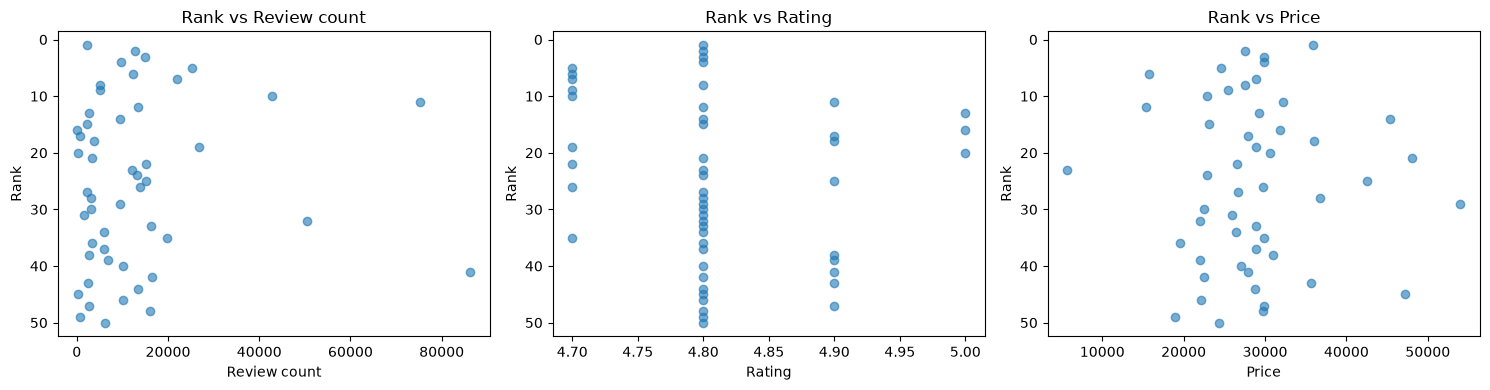

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_to_plot = [('exact_review_count', 'Review count'), ('exact_rating', 'Rating'), ('price_num', 'Price')]

for ax, (col, label) in zip(axes, vars_to_plot):
    ax.scatter(olive[col], olive['rank'], alpha=0.6)
    ax.set_xlabel(label)
    ax.set_ylabel('Rank')
    ax.set_title(f'Rank vs {label}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 8. 결론과 한계

1. 상위 50개 제품 기준으로, 리뷰수·평점·가격·할인율 중 어느 것도 "인기순" 노출 순위와 통계적으로 유의한 상관관계를 보이지 않았음. (모든 p > 0.05)

2. 세 그래프 다 구름처럼 흩어진 모양. Spearman에서 유의하지 않게 나온 게 우연이 아니라 실제로 시각적으로도 관계가 없다는 걸 확인함.
.
3. 평점의 낮은 분산: 아까 봤듯이 평점이 4.7~5.0에 몰려있어서, 애초에 평점으로 순위를 가르기엔 변별력이 부족한 데이터였을 가능성 

4. 표본 크기: 50개면 통계적으로 유의한 관계를 잡아내기엔 좀 작을 수 있음. n이 더 크면 같은 상관계수 값도 유의해질 수 있음

5. 알고리즘 자체의 설계: "인기순"이 리뷰수·평점·가격이 아니라 판매량, 최신성, PICK 상품(브랜드 협찬), 클릭률 같은 다른 신호로 짜여있을 가능성 — 상품명에 "[7월올영픽]" 같은 태그가 많이 보였음.